# Assignment 3 - Tiny Transformer for Next-Token Prediction

Steps:
1. Load the Tiny Shakespeare text.
2. Train a small **Byte-Pair Encoding (BPE)** subword tokenizer (vocab size <= 500).
3. Cut the token stream into overlapping fixed-length `(input, target)` sequences for next-token prediction.
4. Build a Tiny Transformer with sinusoidal positional encoding, causal multi-head self-attention, RMSNorm, and a feed-forward network with residual connections.
5. Train with cross-entropy loss; track train/validation loss and perplexity.
6. Visualize attention heatmaps and generate a short sample from the trained model.

## 1. Setup and Reproducibility

Fix seeds so the run is reproducible, pick the best available device, and import only the libraries we actually need.

In [1]:
# Core imports: PyTorch for the model, Counter for BPE merge counting,
# matplotlib for plots, and urllib to fetch the dataset.
import os
import math
import random
import urllib.request
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


## 2. Load the Tiny Shakespeare Corpus


In [4]:
DATA_PATH = 'tiny_shakespeare.txt'
SHAKESPEARE_URL = (
    'https://raw.githubusercontent.com/karpathy/char-rnn/master/'
    'data/tinyshakespeare/input.txt'
)
if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(SHAKESPEARE_URL, DATA_PATH)

# Read the full text into a single string.
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    text = f.read()

print(f'Corpus length: {len(text):,} characters')
print(f'Unique characters: {len(set(text))}')
print('First 200 characters:')
print(text[:200])

Corpus length: 1,115,394 characters
Unique characters: 65
First 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## 3. Byte-Pair Encoding (BPE) Tokenizer


In [ ]:
class SimpleBPE:
    """Minimal byte-pair encoding tokenizer operating at the character level."""

    def __init__(self, vocab_size: int = 500):
        self.vocab_size = vocab_size
        self.merges = []
        self.id_to_str = {}
        self.str_to_id = {}
        # Cache of the training-corpus encoding so we don't re-encode later.
        self.train_ids = None

    def train(self, text: str):
        """Learn merges by repeatedly combining the most frequent adjacent pair."""
        #  1) Build the base alphabet from unique characters. ---
        chars = sorted(set(text))
        for i, ch in enumerate(chars):
            self.id_to_str[i] = ch
            self.str_to_id[ch] = i

        # 2) Encode the corpus into a list of ids to operate on directly. ---
        ids = [self.str_to_id[c] for c in text]

        #  3) Greedy BPE loop: merge the best pair until vocab is full. ---
        while len(self.id_to_str) < self.vocab_size:
            # Count every adjacent pair in a single pass.
            pair_counts = Counter(zip(ids, ids[1:]))
            if not pair_counts:
                break
            (p0, p1), cnt = pair_counts.most_common(1)[0]
            # If the best pair occurs only once, further merges add no compression.
            if cnt < 2:
                break

            new_id = len(self.id_to_str)
            new_str = self.id_to_str[p0] + self.id_to_str[p1]
            self.id_to_str[new_id] = new_str
            self.str_to_id[new_str] = new_id
            self.merges.append(((p0, p1), new_id))

            merged = []
            i = 0
            while i < len(ids):
                if i < len(ids) - 1 and ids[i] == p0 and ids[i + 1] == p1:
                    merged.append(new_id)
                    i += 2
                else:
                    merged.append(ids[i])
                    i += 1
            ids = merged

        # Cache the final encoded corpus for downstream use.
        self.train_ids = ids

    def encode(self, text: str):
        """Encode arbitrary text by replaying learned merges in order."""
        # Unknown characters (not seen in training) are dropped.
        ids = [self.str_to_id[c] for c in text if c in self.str_to_id]
        for (p0, p1), new_id in self.merges:
            merged = []
            i = 0
            while i < len(ids):
                if i < len(ids) - 1 and ids[i] == p0 and ids[i + 1] == p1:
                    merged.append(new_id)
                    i += 2
                else:
                    merged.append(ids[i])
                    i += 1
            ids = merged
        return ids

    def decode(self, ids):
        """Decode an id sequence back into a string."""
        return ''.join(self.id_to_str[i] for i in ids if i in self.id_to_str)

    @property
    def vocab(self):
        return self.id_to_str


# Train the tokenizer on the full corpus with a tight vocabulary budget.
VOCAB_SIZE = 500
tokenizer = SimpleBPE(vocab_size=VOCAB_SIZE)
tokenizer.train(text)

print(f'Final vocab size: {len(tokenizer.vocab)}')
print(f'Number of learned merges: {len(tokenizer.merges)}')
learned_multichar = [s for s in tokenizer.str_to_id if len(s) > 1][:20]
print('Sample learned subword tokens:', learned_multichar)

Final vocab size: 500
Number of learned merges: 435
Sample learned subword tokens: ['e ', 'th', 't ', 's ', 'd ', ', ', 'ou', 'er', 'in', 'y ', 'an', ':\n', 'or', 'o ', 'en', '\n\n', 'ar', ' th', 'on', 'll']


In [6]:
# Round-trip check: encode and decode a short snippet to verify the tokenizer.
sample = text[:120]
enc = tokenizer.encode(sample)
dec = tokenizer.decode(enc)
print('Original :', repr(sample))
print('Encoded  :', enc[:30], '...')
print(f'Compression: {len(sample)} chars -> {len(enc)} tokens'
      f' ({len(sample)/max(len(enc),1):.2f} chars/token)')
print('Decoded  :', repr(dec))
assert dec == sample, 'BPE round trip failed.'

Original : 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved ra'
Encoded  : [18, 438, 15, 125, 47, 64, 79, 76, 14, 43, 464, 347, 415, 41, 135, 69, 75, 74, 44, 142, 177, 70, 334, 499, 282, 383, 87, 13, 84, 76] ...
Compression: 120 chars -> 55 tokens (2.18 chars/token)
Decoded  : 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved ra'


## 4. Sequence Formatting and Train/Val Split

For next-token prediction, each training example is a pair `(input, target)` where `target` is `input` shifted by one position. We take overlapping windows over the token stream with a small stride to get many training examples from a single corpus.

In [ ]:
SEQ_LEN = 64   # number of tokens per training window (context length)
STRIDE  = 32   # step between consecutive windows; smaller stride -> more overlap

# Use the token id stream we already cached during tokenizer training.
token_ids = tokenizer.train_ids
print(f'Total tokens in corpus: {len(token_ids):,}')

# Build (input, target) windows. We need SEQ_LEN + 1 tokens per window because
inputs, targets = [], []
for start in range(0, len(token_ids) - SEQ_LEN - 1, STRIDE):
    chunk = token_ids[start : start + SEQ_LEN + 1]
    inputs.append(chunk[:-1])   # tokens 0..N-1
    targets.append(chunk[1:])   # tokens 1..N (shifted by one)

inputs  = torch.tensor(inputs,  dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)
print(f'Input tensor shape : {tuple(inputs.shape)}')
print(f'Target tensor shape: {tuple(targets.shape)}')

Total tokens in corpus: 506,296
Input tensor shape : (15820, 64)
Target tensor shape: (15820, 64)


In [8]:
class NextTokenDataset(Dataset):
    """Wrap (inputs, targets) tensors in a standard PyTorch Dataset."""

    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return self.inputs.size(0)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]


full_dataset = NextTokenDataset(inputs, targets)

# 80/20 train/val split using a fixed generator for reproducibility.
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_set, val_set = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)
print(f'Train sequences: {len(train_set):,} | Val sequences: {len(val_set):,}')

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)

Train sequences: 12,656 | Val sequences: 3,164


## 5. Tiny Transformer Components

Each component is implemented by hand so we can trace every tensor shape:
- **Sinusoidal positional encoding** injects position information into the token embedding.
- **RMSNorm** is a lightweight alternative to LayerNorm used in modern LLMs (LLaMA, etc.).
- **Causal multi-head self-attention** uses a triangular mask so position `t` only attends to positions `<= t`.
- **Feed-forward network** (position-wise MLP) with GELU, wrapped by residual connections.

In [9]:
def sinusoidal_positional_encoding(max_len: int, d_model: int) -> torch.Tensor:
    """Classic sin/cos positional encoding from 'Attention Is All You Need'.

    Returns a tensor of shape (max_len, d_model) where even dimensions use sin
    and odd dimensions use cos, with geometrically spaced wavelengths.
    """
    # Precompute (position, dim) as a broadcastable grid.
    position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)   # (L, 1)
    # The -log(10000)/d_model factor controls how quickly frequencies decay.
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float32)
        * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)  # even indices -> sin
    pe[:, 1::2] = torch.cos(position * div_term)  # odd indices  -> cos
    return pe

In [10]:
class RMSNorm(nn.Module):
    """Root-Mean-Square LayerNorm.

    Like LayerNorm but drops the mean-centering step: only rescales by the
    root-mean-square of features. Cheaper and empirically as effective in LLMs.
    """

    def __init__(self, d_model: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        # Learned per-feature scale (initialized to 1 so the layer starts as a no-op).
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Compute RMS along the last dim, then rescale and apply learned gain.
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return (x / rms) * self.weight

In [11]:
class CausalMultiHeadAttention(nn.Module):
    """Multi-head self-attention with a causal (upper-triangular) mask."""

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1,
                 max_len: int = 512):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # per-head feature dim

        # One fused linear that produces Q, K, V in a single matmul.
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # Pre-built causal mask stored as a buffer (moves with .to(device)).
        mask = torch.triu(torch.ones(max_len, max_len), diagonal=1).bool()
        self.register_buffer('causal_mask', mask, persistent=False)

        # Slot to stash the last attention map for visualization. Not a parameter.
        self.last_attn_weights = None

    def forward(self, x: torch.Tensor, store_attn: bool = False) -> torch.Tensor:
        B, T, D = x.shape

        # --- Project into Q, K, V and split heads ---
        qkv = self.qkv_proj(x)                          # (B, T, 3D)
        q, k, v = qkv.split(self.d_model, dim=-1)       # each (B, T, D)
        # Reshape each into (B, num_heads, T, d_k) so attention is per-head.
        q = q.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        # --- Scaled dot-product attention scores ---
        # (B, H, T, d_k) x (B, H, d_k, T) -> (B, H, T, T)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply causal mask: positions in the future get -inf so softmax -> 0.
        scores = scores.masked_fill(self.causal_mask[:T, :T], float('-inf'))
        attn = F.softmax(scores, dim=-1)

        # Cache attention weights (detached) for later heatmap visualization.
        if store_attn:
            self.last_attn_weights = attn.detach()

        attn = self.attn_dropout(attn)

        # --- Weighted sum of values, then merge heads and project out ---
        out = attn @ v                                  # (B, H, T, d_k)
        out = out.transpose(1, 2).contiguous().view(B, T, D)  # (B, T, D)
        return self.resid_dropout(self.out_proj(out))

In [12]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network: Linear -> GELU -> Linear -> Dropout."""

    def __init__(self, d_model: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, ffn_dim)
        self.fc2 = nn.Linear(ffn_dim, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # GELU is the standard non-linearity in modern Transformers (BERT, GPT-2+).
        return self.dropout(self.fc2(F.gelu(self.fc1(x))))


class TransformerBlock(nn.Module):
    """Pre-norm Transformer block: x -> x + Attn(RMSNorm(x)) -> x + FFN(RMSNorm(x)).

    Pre-norm (normalize before the sublayer) is more stable to train than the
    original post-norm formulation and is what modern LLMs use.
    """

    def __init__(self, d_model: int, num_heads: int, ffn_dim: int,
                 dropout: float = 0.1, max_len: int = 512):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = CausalMultiHeadAttention(d_model, num_heads, dropout, max_len=max_len)
        self.norm2 = RMSNorm(d_model)
        self.ffn = FeedForward(d_model, ffn_dim, dropout)

    def forward(self, x: torch.Tensor, store_attn: bool = False) -> torch.Tensor:
        # Residual #1: attention over the normalized input.
        x = x + self.attn(self.norm1(x), store_attn=store_attn)
        # Residual #2: feed-forward over the normalized result.
        x = x + self.ffn(self.norm2(x))
        return x

In [ ]:
class TinyTransformer(nn.Module):
    """Decoder-only Transformer language model (GPT-style, but tiny)."""

    def __init__(self, vocab_size: int, d_model: int = 128, num_heads: int = 4,
                 num_layers: int = 2, ffn_dim: int = 256, max_len: int = 64,
                 dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        # Token embedding lookup table.
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # Fixed (non-learned) sinusoidal positional encoding stored as a buffer.
        self.register_buffer(
            'pos_enc', sinusoidal_positional_encoding(max_len, d_model),
            persistent=False,
        )
        self.emb_dropout = nn.Dropout(dropout)

        # Stack of Transformer blocks.
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, ffn_dim, dropout, max_len=max_len)
            for _ in range(num_layers)
        ])
        # Final norm before projecting to vocabulary logits.
        self.final_norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: share the embedding matrix with the output projection.
        # This reduces parameters and often improves language modeling.
        self.lm_head.weight = self.token_emb.weight

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, store_attn: bool = False) -> torch.Tensor:
        B, T = idx.shape
        assert T <= self.max_len, f'Sequence length {T} exceeds max_len {self.max_len}'

        # Token embeddings + positional encoding (broadcasted over batch).
        x = self.token_emb(idx) + self.pos_enc[:T].unsqueeze(0)
        x = self.emb_dropout(x)

        # Pass through each Transformer block sequentially.
        for block in self.blocks:
            x = block(x, store_attn=store_attn)

        # Final norm + linear projection to vocabulary logits.
        x = self.final_norm(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)
        return logits


# Instantiate the model with the hyperparameters the assignment suggests. 
D_MODEL   = 128
NUM_HEADS = 4
NUM_LAYERS = 2
FFN_DIM   = 256
DROPOUT   = 0.1

model = TinyTransformer(
    vocab_size=len(tokenizer.vocab),
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ffn_dim=FFN_DIM,
    max_len=SEQ_LEN,
    dropout=DROPOUT,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'Total parameters: {num_params:,}')

TinyTransformer(
  (token_emb): Embedding(500, 128)
  (emb_dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (norm1): RMSNorm()
      (attn): CausalMultiHeadAttention(
        (qkv_proj): Linear(in_features=128, out_features=384, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): RMSNorm()
      (ffn): FeedForward(
        (fc1): Linear(in_features=128, out_features=256, bias=True)
        (fc2): Linear(in_features=256, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (final_norm): RMSNorm()
  (lm_head): Linear(in_features=128, out_features=500, bias=False)
)
Total parameters: 328,576


## 6. Training

Train with cross-entropy loss on the next-token prediction task. We track train/validation loss per epoch and log validation perplexity (`PPL = exp(val_loss)`) as the main metric.

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Average cross-entropy over a dataloader. Uses no_grad for speed/memory."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        # Flatten (B, T, V) -> (B*T, V) and (B, T) -> (B*T) for cross-entropy.
        loss = criterion(logits.view(-1, logits.size(-1)), yb.view(-1))
        # Weight by number of tokens so variable batch sizes average correctly.
        total_loss += loss.item() * yb.numel()
        total_tokens += yb.numel()
    return total_loss / total_tokens


LR = 3e-4
EPOCHS = 15
GRAD_CLIP = 1.0  # clip gradient norm to stabilize training

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, betas=(0.9, 0.95), weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    tokens_seen = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits.view(-1, logits.size(-1)), yb.view(-1))

        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping prevents exploding gradients on noisy batches.
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        running += loss.item() * yb.numel()
        tokens_seen += yb.numel()

    train_loss = running / tokens_seen
    val_loss = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'Epoch {epoch:02d} | train loss {train_loss:.4f} | '
          f'val loss {val_loss:.4f} | val PPL {math.exp(val_loss):.2f}')

Epoch 01 | train loss 5.8054 | val loss 5.7654 | val PPL 319.05
Epoch 02 | train loss 5.7692 | val loss 5.7650 | val PPL 318.93
Epoch 03 | train loss 5.7688 | val loss 5.7651 | val PPL 318.99
Epoch 04 | train loss 5.7683 | val loss 5.7643 | val PPL 318.73
Epoch 05 | train loss 5.7648 | val loss 5.7191 | val PPL 304.64
Epoch 06 | train loss 5.5409 | val loss 5.4146 | val PPL 224.66
Epoch 07 | train loss 5.3112 | val loss 5.1509 | val PPL 172.58
Epoch 08 | train loss 5.0752 | val loss 4.9655 | val PPL 143.38
Epoch 09 | train loss 4.9496 | val loss 4.8718 | val PPL 130.55
Epoch 10 | train loss 4.8556 | val loss 4.7415 | val PPL 114.61
Epoch 11 | train loss 4.7234 | val loss 4.6254 | val PPL 102.04
Epoch 12 | train loss 4.6200 | val loss 4.5280 | val PPL 92.58
Epoch 13 | train loss 4.5436 | val loss 4.4502 | val PPL 85.65
Epoch 14 | train loss 4.4734 | val loss 4.3775 | val PPL 79.64
Epoch 15 | train loss 4.4118 | val loss 4.3316 | val PPL 76.07


## 7. Loss Curves and Validation Perplexity

Loss should decrease over epochs. Perplexity is `exp(val_loss)` - the lower, the better.

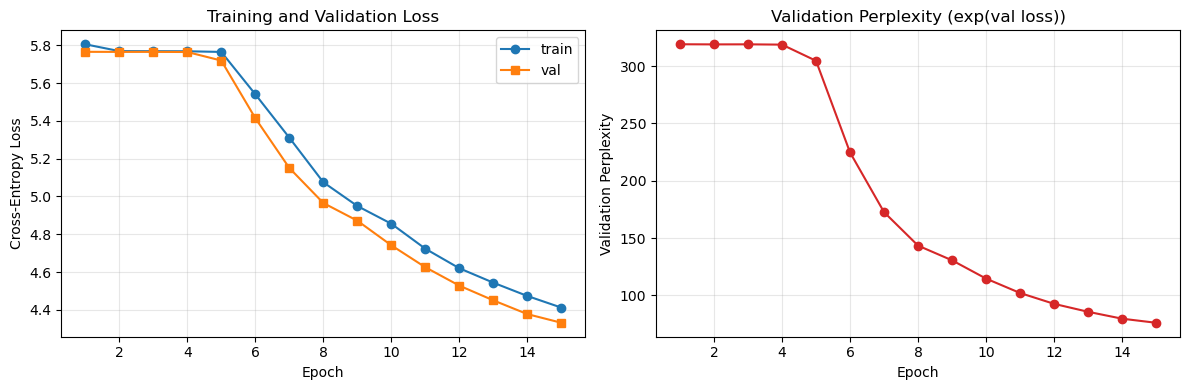

Final validation loss: 4.3316
Final validation perplexity: 76.07


In [15]:
# Plot training vs. validation cross-entropy and validation perplexity side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS + 1), train_losses, label='train', marker='o')
axes[0].plot(range(1, EPOCHS + 1), val_losses,   label='val',   marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

val_ppl = [math.exp(l) for l in val_losses]
axes[1].plot(range(1, EPOCHS + 1), val_ppl, color='tab:red', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Perplexity')
axes[1].set_title('Validation Perplexity (exp(val loss))')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_val_loss = val_losses[-1]
print(f'Final validation loss: {final_val_loss:.4f}')
print(f'Final validation perplexity: {math.exp(final_val_loss):.2f}')

## 8. Attention Heatmaps

Run a single validation batch through the model with `store_attn=True`, then visualize the attention matrix for each head in each layer on one sample. Because of the causal mask, attention is strictly lower-triangular (a token can only attend to itself and earlier positions).

In [ ]:
# Grab a single sample from the validation set for visualization.
sample_idx = 0
sample_input, sample_target = val_set[sample_idx]
sample_input = sample_input.unsqueeze(0).to(device)   # (1, T)

# Forward pass with attention storage enabled.
model.eval()
with torch.no_grad():
    _ = model(sample_input, store_attn=True)

# Decode individual tokens for axis labels (one token per id).
tokens = [tokenizer.id_to_str[i.item()] for i in sample_input[0].cpu()]
display_tokens = [t.replace('\n', '\u21b5').replace(' ', '\u2423') for t in tokens]
T = len(tokens)
print(f'Visualizing attention over sequence of length {T}.')
print('Sample text:', repr(''.join(tokens)))

Visualizing attention over sequence of length 64.
Sample text: "s.\nBut, leaving this, what is your grace's pleasure?\n\nBUCKINGHAM:\nEven that, I hope, which pleaseth God above,\nAnd all good men of this ungo"


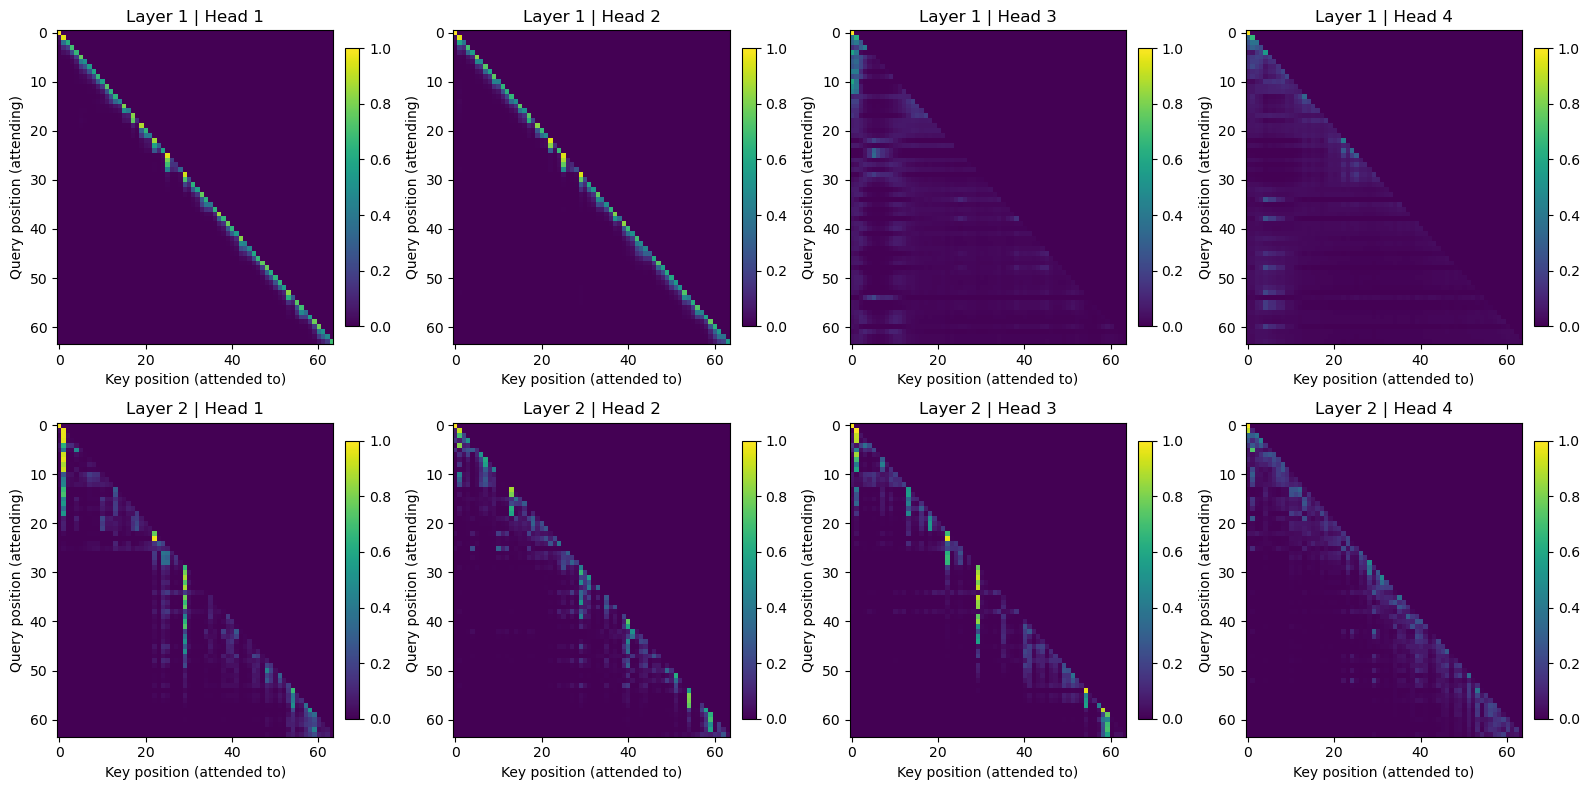

In [ ]:
# Plot one heatmap per (layer, head). Each row of the matrix is a query position,
# each column is a key position. Causal mask -> upper triangle is all zero.
fig, axes = plt.subplots(
    NUM_LAYERS, NUM_HEADS, figsize=(4 * NUM_HEADS, 4 * NUM_LAYERS), squeeze=False,
)

for layer_idx, block in enumerate(model.blocks):
    # Shape: (1, num_heads, T, T)
    attn_weights = block.attn.last_attn_weights.cpu().numpy()[0]
    for head_idx in range(NUM_HEADS):
        ax = axes[layer_idx][head_idx]
        im = ax.imshow(attn_weights[head_idx], cmap='viridis', aspect='auto')
        ax.set_title(f'Layer {layer_idx + 1} | Head {head_idx + 1}')
        ax.set_xlabel('Key position (attended to)')
        ax.set_ylabel('Query position (attending)')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

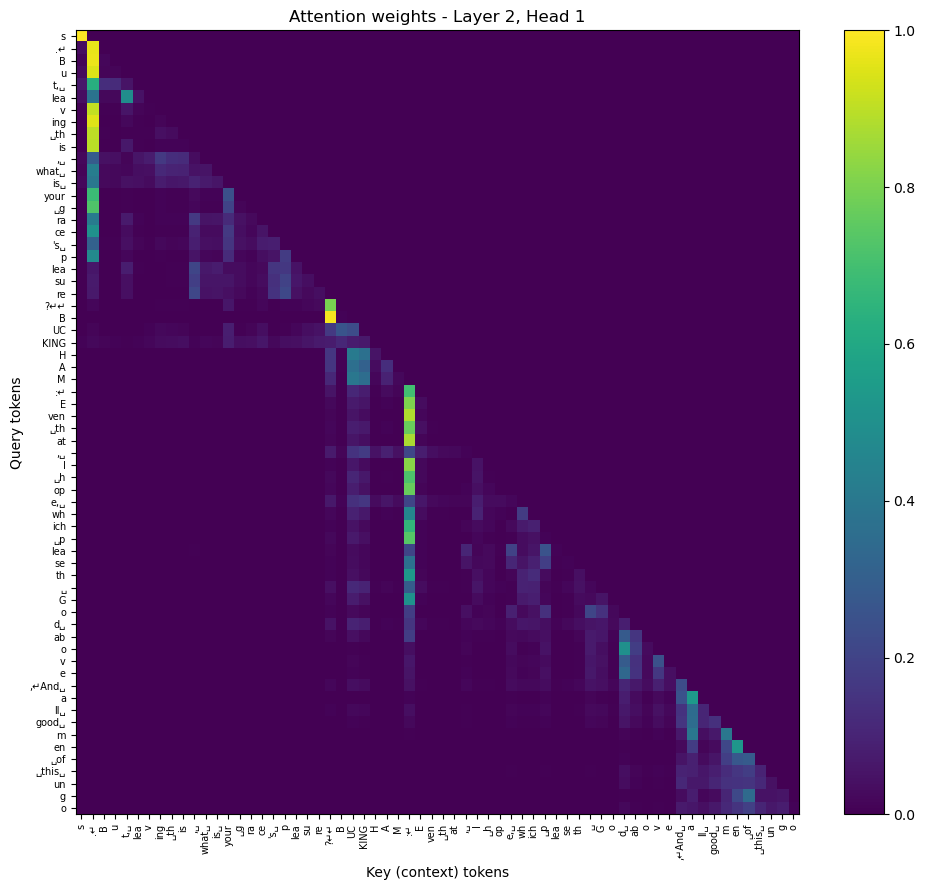

In [17]:
# Zoom-in: plot one layer/head with token-level labels on both axes so we can
# read which token attends to which.
layer_to_view = NUM_LAYERS - 1   # last layer tends to show richer patterns
head_to_view  = 0
attn_matrix = (
    model.blocks[layer_to_view].attn.last_attn_weights[0, head_to_view].cpu().numpy()
)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(attn_matrix, cmap='viridis', aspect='auto')
ax.set_xticks(range(T))
ax.set_yticks(range(T))
ax.set_xticklabels(display_tokens, rotation=90, fontsize=7)
ax.set_yticklabels(display_tokens, fontsize=7)
ax.set_title(f'Attention weights - Layer {layer_to_view + 1}, Head {head_to_view + 1}')
ax.set_xlabel('Key (context) tokens')
ax.set_ylabel('Query tokens')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 9. Sample Generation

Autoregressive sampling: start from a short prompt, repeatedly sample the next token from the model, and feed it back in. Temperature scales the sharpness of the softmax - lower means more conservative, higher means more random.

In [ ]:
@torch.no_grad()
def generate(model, tokenizer, prompt: str, max_new_tokens: int = 200,
             temperature: float = 0.8, top_k: int | None = 40) -> str:
    """Autoregressively sample tokens given a prompt."""
    model.eval()
    # Encode the prompt; if empty, start with a random token.
    ids = tokenizer.encode(prompt) or [random.randrange(len(tokenizer.vocab))]
    idx = torch.tensor([ids], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.max_len:]
        logits = model(idx_cond)[:, -1, :]        
        logits = logits / max(temperature, 1e-8)  

        if top_k is not None:
            # Zero out all but the top-k most probable tokens for cleaner samples.
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('inf')

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)  # stochastic sample
        idx = torch.cat([idx, next_id], dim=1)

    return tokenizer.decode(idx[0].tolist())


# Generate a short passage starting from a Shakespeare-flavored prompt.
print('--- Sample generation ---')
print(generate(model, tokenizer, prompt='ROMEO:', max_new_tokens=300, temperature=0.8))

--- Sample generation ---
ROMEO: he tontalt, is the carges!

LUCEO:
Ay bood the drovecondlsind to yous abrariiv,
What not it the conthink not meeseds inter at the flapy.
The make ther that astank an, for the cuse her,
This as is that mall fow'd surt sin this comredle bate
Cour stonted my fraves as your bught and to the blook the dentory wand,
To mative thorts sir: at in drer mell
Whan purds say you may, whese I know all is for the cent.

DUKE IISTER:
Who is not intrave so fiy to govert sase
Here: when wouting to the feaven would thans:
An aterd my bood of therby your mups to stoot gregles,
Whave mall so nrard, and my father, that the mread.

BRUCUMIO:
Dy, your move to thy 


## 10. Summary

- The Tiny Transformer (2 layers, d_model=128, 4 heads) trains to a substantially lower validation perplexity than a uniform-guess baseline of `VOCAB_SIZE`.
- Attention heatmaps respect the causal mask (strictly lower-triangular) and show distinct per-head patterns: some heads attend strongly to recent tokens, others spread across the sequence.
- Sample generation produces Shakespeare-like character names and formatting even if the content is not semantically coherent, which is the expected behavior for such a small model and corpus.